In [24]:
# ファイルから特定の列、行を抽出
import os
import numpy as np
import pandas as pd
from pathlib import Path

file_path = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\FC\89FCSED.xls"

SED89FC = (
    pd.read_excel(file_path)
    .iloc[2:7, [4]]  # 2行目から7行目まで、4列目を抽出
    .assign(Freezing = lambda df: df['Interval.3'] / 60 * 100 ) # Freezing列を追加
    [['Freezing']]
    .assign(
        # Time列に1から行数までの連番を追加
        Time  = lambda df: list(range(1, len(df) + 1)),
        # No列にpathからファイル名を抽出して追加
        No = lambda df: Path(file_path).stem,  
        Group = lambda df: np.select(
            # 条件のリスト：No列に各文字列が含まれているか
            condlist=[
                df['No'].str.contains('SED'),
                df['No'].str.contains('LIE'),
                df['No'].str.contains('MOE')
            ],
            # 条件にマッチしたときに入れる値のリスト
            choicelist=['SED', 'LIE', 'MOE'],
            # どれにも当てはまらない場合のデフォルト値
            default='Other'
        )
    )
)

print(SED89FC)


    Freezing  Time       No Group
2   5.266667     1  89FCSED   SED
3        0.0     2  89FCSED   SED
4        0.0     3  89FCSED   SED
5       53.8     4  89FCSED   SED
6  81.833333     5  89FCSED   SED


In [7]:

import os
import numpy as np
import pandas as pd
from pathlib import Path

# 自動でエクセルファイルを読み込む

folder = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\FC"

files = sorted(Path(folder).glob("*.xls"))

if not files:
    print(f"{folder} の中に .xls ファイルはありません")
else:
    dfs = []
    for file in files:
        df = (
        pd.read_excel(file)
        .iloc[2:8, [4]]  # 2行目から7行目まで、4列目を抽出
        .assign(Freezing = lambda df: df['Interval.3'] / 60 * 100 ) # Freezing列を追加
        [['Freezing']]
        .assign(
        # Time列に1から行数までの連番を追加
        Time  = lambda df: list(range(1, len(df) + 1)),
        # No列にpathからファイル名を抽出して追加
        No = lambda df: Path(file).stem,  # noqa: B023
        Group = lambda df: np.select(
            # 条件のリスト：No列に各文字列が含まれているか
            condlist=[
                df['No'].str.contains('SED'),
                df['No'].str.contains('LIE'),
                df['No'].str.contains('MOE')
            ],
            # 条件にマッチしたときに入れる値のリスト
            choicelist=['SED', 'LIE', 'MOE'],
            # どれにも当てはまらない場合のデフォルト値
            default='Other'
            )
        )
     )
        dfs.append(df)

    dataFC = pd.concat(dfs, ignore_index=True)
    print(f"{len(files)} 件の .xls ファイルを読み込みました")
    print(dataFC)

24 件の .xls ファイルを読み込みました
      Freezing  Time        No Group
0          0.0     1  100FCMOE   MOE
1          0.0     2  100FCMOE   MOE
2          0.0     3  100FCMOE   MOE
3         47.6     4  100FCMOE   MOE
4         43.5     5  100FCMOE   MOE
..         ...   ...       ...   ...
139        0.0     2   99FCMOE   MOE
140        0.0     3   99FCMOE   MOE
141  14.566667     4   99FCMOE   MOE
142       60.8     5   99FCMOE   MOE
143  71.966667     6   99FCMOE   MOE

[144 rows x 4 columns]


In [11]:
# データセットをグラフ用に整形する
import numpy as np
import pandas as pd

sumFC = (
    dataFC.groupby(['Group', 'Time'])['Freezing'] # 各グループ・時間ごとに、凍結量の値を見て集計する
    .agg(
        # **{...} は、辞書を agg() のキーワード引数として展開する書き方
        **{'Freezing Time (%)': 'mean'} # 各グループごとの平均値を計算

        # 手動でSEを計算する場合は、以下のように書くこともできる (PythonではSEをグラフの描画のために事前計算する必要はない)
        # 'seFreezing': lambda x: np.std(x, ddof=1) / np.sqrt(len(x))}
    )
    .reset_index() # Group と Time がインデックスではなく列として残る形に変換
)

# Group列をカテゴリ型に変換し、'SED'を基準（先頭）に並べ替える
sumFC["Group"] = pd.Categorical(
    sumFC["Group"],
    # 「カテゴリの順番」を決定
    categories=["SED"] + [c for c in sumFC["Group"].unique() if c != "SED"], #「SED を最初に置き、残りは元の出現順に続ける」という順序を定義
    ordered=True, #順序を意味のある並び順として扱えるようになる
)


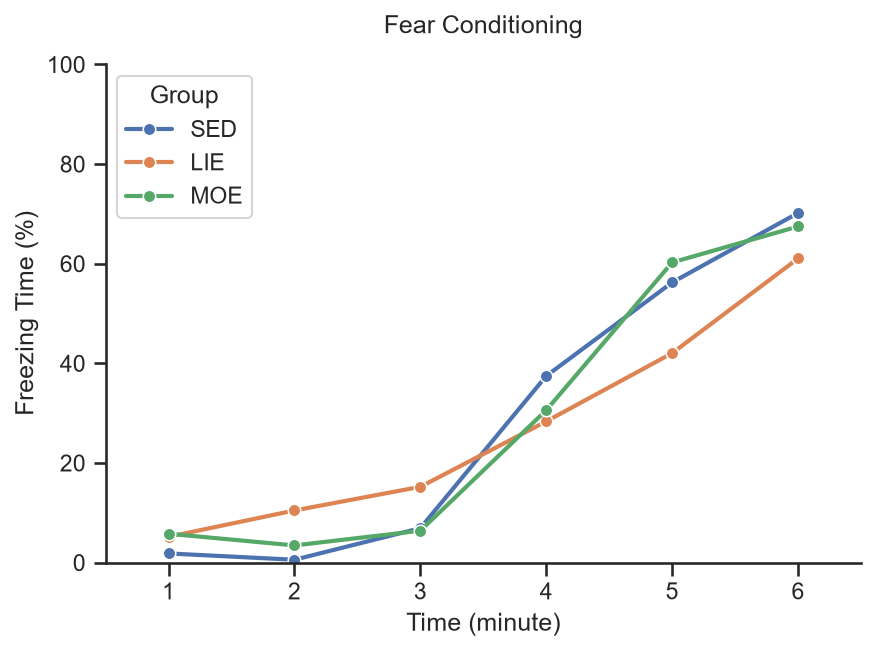

In [18]:
# 調整したデータでグラフを作成
import matplotlib.pyplot as plt
import seaborn as sns

# グラフのスタイルとサイズを設定
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 4.5))

# 折れ線グラフ（エラーバー付き）を描画
PlotFC = sns.lineplot(
    data=sumFC,
    x="Time",
    y="Freezing Time (%)",
    hue="Group",
    marker="o",  # 各データ点にマーカーを表示
    linewidth=2,
    errorbar="se",  #  これだけでSEが自動計算
    err_style="bars",  #  面（シェード）ではなく、エラーバー（線）で表示する指定
)

# 手動で標準誤差（SE）のエラーバーを追加する場合は以下
# for group, df_group in sumFC.groupby("Group"):
#     plt.errorbar(
#         x=df_group["Time"],
#         y=df_group["Freezing Time (%)"],
#         yerr=df_group["seFreezing"],
#         fmt="none",  # 線やマーカーは引かない（lineplotと重複させないため）
#         capsize=4,  # エラーバーの端の横線
#     )

# 軸の範囲とラベルの設定
plt.xlim(0.5, 6.5)
plt.xticks(range(1, 7))  # 1, 2, 3, 4, 5, 6 minute
plt.ylim(0, 100)  # 0 ~ 100%

plt.xlabel("Time (minute)")
plt.ylabel("Freezing Time (%)")
plt.title("Fear Conditioning", pad=15)

# グラフの枠線を整理して表示
sns.despine()
plt.tight_layout()
plt.show()


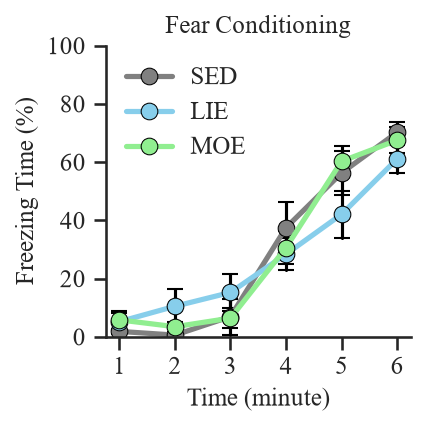

In [71]:
# seabornを使ったグラフ描画
# この書き方で事前データを作成する必要はない (seabornのlineplotで自動計算されるため)
import logging
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import pandas as pd

# 保存するディレクトリを作成
save_dir = Path(r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots")
save_dir.mkdir(parents=True, exist_ok=True)

# Times New Roman の実ファイルを直接指定
# font_path = r"C:\Windows\Fonts\times.ttf"
# fm.fontManager.addfont(font_path)

# フォント設定
# plt.rcParams["font.family"] = ["Times New Roman", "DejaVu Serif", "serif"]
# plt.rcParams["axes.unicode_minus"] = False  # マイナス記号を正しく表示するための設定

# フォントを固定
font_prop = font_manager.FontProperties(family="Times New Roman")

# 描画順と色
group_order = ["SED", "LIE", "MOE"]
palette = {
    "SED": "gray",
    "LIE": "skyblue",
    "MOE": "lightgreen",
}

sns.set_theme(style="ticks")

fig, ax = plt.subplots(figsize=(3, 3))

sns.lineplot(
    data=dataFC,
    x="Time",
    y="Freezing",
    hue="Group",
    hue_order=group_order,
    palette=palette,
    estimator="mean",
    errorbar="se",
    marker="o",
    markersize=8,
    linewidth=2.5,
    err_style="bars",
    err_kws={
        "ecolor": "black", 
        "elinewidth": 1.5, 
        "capsize": 4,
        "zorder": 1
    },
    markeredgecolor="black",
    markeredgewidth=.5,
    ax=ax
)

# 軸範囲
ax.set_ylim(0, 100)
ax.set_yticks([0, 20, 40, 60, 80, 100])
# ax.set_xlim(1, 6)
ax.set_xticks([1, 2, 3, 4, 5, 6])

# ラベル・タイトルとフォントサイズ
ax.set_title("Fear Conditioning", fontsize=14, fontproperties=font_prop)
ax.set_xlabel("Time (minute)", fontsize=12, fontproperties=font_prop)
ax.set_ylabel("Freezing Time (%)", fontsize=12, fontproperties=font_prop)

# 軸目盛りのフォントも強制指定
ax.tick_params(axis="both", labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font_prop)

# 凡例: 左上、枠なし、タイトルなし
legend = ax.legend(title=None, loc="upper left", frameon=False)
for text in legend.get_texts():
    text.set_fontproperties(font_prop)

# グラフの枠線を整理して表示
sns.despine()
plt.tight_layout()

# 各形式で保存
plt.savefig(save_dir / "FearConditioning_seaborn.pdf", dpi=300, bbox_inches="tight")
plt.savefig(save_dir / "FearConditioning_seaborn.svg", dpi=300, bbox_inches="tight")
plt.savefig(save_dir / "FearConditioning_seaborn.tiff", dpi=300, bbox_inches="tight")
plt.savefig(save_dir / "FearConditioning_seaborn.png", dpi=300, bbox_inches="tight")

plt.show()

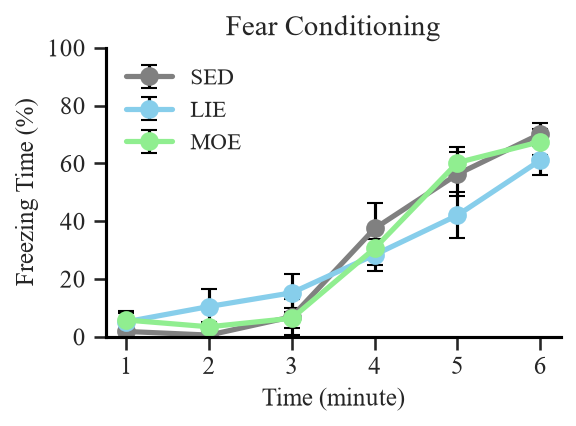

In [50]:
# Matplotlibでその場計算しながら描画
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Times New Roman"

group_order = ["SED", "LIE", "MOE"]
palette = {
    "SED": "gray",
    "LIE": "skyblue",
    "MOE": "lightgreen",
}

fig, ax = plt.subplots(figsize=(4, 3))

for group in group_order:
    df = dataFC[dataFC["Group"] == group]
    summary = (
        df.groupby("Time")["Freezing"]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    summary["se"] = summary["std"] / np.sqrt(summary["n"])

    ax.errorbar(
        summary["Time"],
        summary["mean"],
        yerr=summary["se"],
        fmt="o-",
        color=palette[group],
        ecolor="black",
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        linewidth=2.5,
        label=group
    )

# グリッドなし
ax.grid(False)

# 上と右の枠線を消し、左右の軸線だけ黒にする
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# 軸範囲
ax.set_ylim(0, 100)
ax.set_yticks([0, 20, 40, 60, 80, 100])
# ax.set_xlim(1, 6)
ax.set_xticks([1, 2, 3, 4, 5, 6])

ax.set_title("Fear Conditioning", fontsize=14)
ax.set_xlabel("Time (minute)", fontsize=12)
ax.set_ylabel("Freezing Time (%)", fontsize=12)

# 目盛り
ax.tick_params(axis="both", labelsize=12)

# 凡例: 左上、枠なし、タイトルなし
ax.legend(title=None, loc="upper left", frameon=False)

plt.tight_layout()
sns.despine()
plt.show()

In [57]:
import matplotlib.font_manager as fm

font_names = sorted({f.name for f in fm.fontManager.ttflist})
for name in font_names:
    if "Times" in name or "Roman" in name:
        print(name)

Informal Roman
Times New Roman
